In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.svm import SVC, SVR
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix, accuracy_score, r2_score,mean_absolute_error, mean_squared_error
from sklearn.metrics import auc, accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score, precision_score, recall_score, f1_score
from scipy.stats import ks_2samp
import plotly.express as px
import sys

import warnings
warnings.filterwarnings('ignore')


%matplotlib inline

## Simple SVC

In [2]:
X,y=make_classification(n_samples=100000,n_features=2,n_clusters_per_class=1,n_classes=2,n_redundant=0,random_state=584)

In [3]:
X

array([[ 0.87276037, -1.35197585],
       [-0.73031518, -0.20770278],
       [-0.59775333,  0.11929971],
       ...,
       [-0.82838515, -0.56036251],
       [-0.95397574, -0.84788244],
       [ 0.93004453, -1.21954429]], shape=(100000, 2))

In [4]:
y

array([1, 0, 0, ..., 0, 0, 1], shape=(100000,))

<Axes: xlabel='Feature1', ylabel='Feature2'>

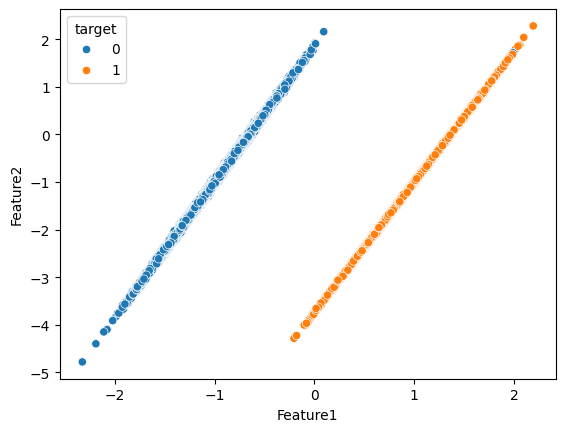

In [6]:
df = pd.DataFrame(X, columns=["Feature1", "Feature2"])
df["target"] = y

sns.scatterplot(data=df, x="Feature1", y="Feature2", hue="target")

In [7]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=584)

In [10]:
print("Shape of X- Train: ",X_train.shape)
print("Shape of X- Test: ",X_test.shape)
print("Shape of y- Train: ",y_train.shape)
print("Shape of y- Test: ",y_test.shape)

Shape of X- Train:  (70000, 2)
Shape of X- Test:  (30000, 2)
Shape of y- Train:  (70000,)
Shape of y- Test:  (30000,)


In [14]:
svc = SVC(kernel='linear', probability=True)
svc.fit(X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


========== Train Metrics ==========
Accuracy       : 0.9953
AUC            : 0.9951
GINI           : 0.9902
KS Statistic   : 0.9907
KS p-value     : 0.0000

========== Classification Report ==========
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     34947
           1       1.00      1.00      1.00     35053

    accuracy                           1.00     70000
   macro avg       1.00      1.00      1.00     70000
weighted avg       1.00      1.00      1.00     70000


========== Confusion Matrix ==========
[[34785   162]
 [  165 34888]]

========== ROC Curve ==========


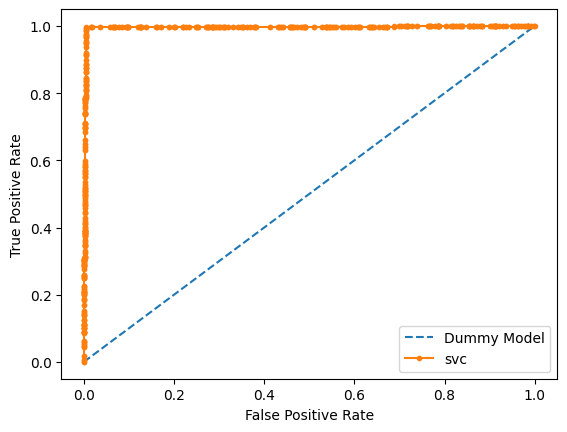

In [15]:
x_pred_svc = svc.predict(X_train)
x_prob_svc  = svc.predict_proba(X_train)[:, 1]

accuracy = accuracy_score(y_train, x_pred_svc )
auc = roc_auc_score(y_train, x_prob_svc )
gini = 2 * auc - 1
ks_stat, ks_pvalue = ks_2samp(x_prob_svc [y_train == 0], x_prob_svc [y_train == 1])

print("========== Train Metrics ==========")
print(f"Accuracy       : {accuracy:.4f}")
print(f"AUC            : {auc:.4f}")
print(f"GINI           : {gini:.4f}")
print(f"KS Statistic   : {ks_stat:.4f}")
print(f"KS p-value     : {ks_pvalue:.4f}")

print("\n========== Classification Report ==========")
print(classification_report(y_train, x_pred_svc ))

print("\n========== Confusion Matrix ==========")
print(confusion_matrix(y_train, x_pred_svc ))

print("\n========== ROC Curve ==========")
dummy_model_prob = [0 for _ in range(len(y_train))]
dummy_fpr, dummy_tpr, _ = roc_curve(y_train, dummy_model_prob)
model_fpr, model_tpr, thresholds = roc_curve(y_train, x_prob_svc)

# plot the roc curve for the model
plt.plot(dummy_fpr, dummy_tpr, linestyle='--', label='Dummy Model')
plt.plot(model_fpr, model_tpr, marker='.', label='svc')
# axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# show the legend
plt.legend()
# show the plot
plt.show()

========== Test Metrics ==========
Accuracy       : 0.9951
AUC            : 0.9948
GINI           : 0.9895
KS Statistic   : 0.9901
KS p-value     : 0.0000

========== Classification Report ==========
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     15080
           1       0.99      1.00      1.00     14920

    accuracy                           1.00     30000
   macro avg       1.00      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000


========== Confusion Matrix ==========
[[14991    89]
 [   59 14861]]

========== ROC Curve ==========


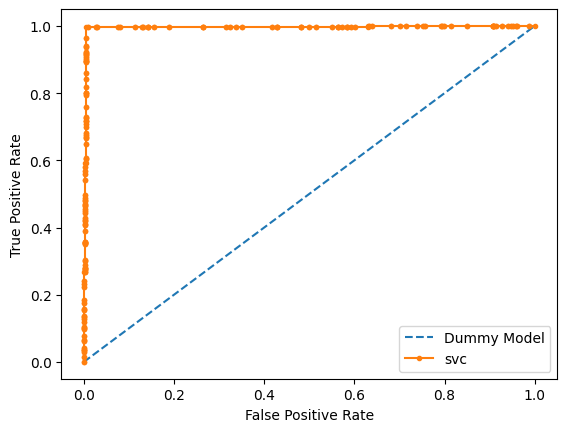

In [16]:
y_pred_svc = svc.predict(X_test)
y_prob_svc  = svc.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred_svc )
auc = roc_auc_score(y_test, y_prob_svc )
gini = 2 * auc - 1
ks_stat, ks_pvalue = ks_2samp(y_prob_svc [y_test == 0], y_prob_svc [y_test == 1])

print("========== Test Metrics ==========")
print(f"Accuracy       : {accuracy:.4f}")
print(f"AUC            : {auc:.4f}")
print(f"GINI           : {gini:.4f}")
print(f"KS Statistic   : {ks_stat:.4f}")
print(f"KS p-value     : {ks_pvalue:.4f}")

print("\n========== Classification Report ==========")
print(classification_report(y_test, y_pred_svc ))

print("\n========== Confusion Matrix ==========")
print(confusion_matrix(y_test, y_pred_svc ))

print("\n========== ROC Curve ==========")
dummy_model_prob = [0 for _ in range(len(y_test))]
dummy_fpr, dummy_tpr, _ = roc_curve(y_test, dummy_model_prob)
model_fpr, model_tpr, thresholds = roc_curve(y_test, y_prob_svc)

# plot the roc curve for the model
plt.plot(dummy_fpr, dummy_tpr, linestyle='--', label='Dummy Model')
plt.plot(model_fpr, model_tpr, marker='.', label='svc')
# axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# show the legend
plt.legend()
# show the plot
plt.show()

#### Since the data points are linearly separable, the SVC model achieves very high accuracy. Let’s repeat the same exercise on a synthetic dataset where the classes are not perfectly linearly separable, by creating two overlapping clusters.

In [19]:
X,y=make_classification(n_samples=10000,n_features=2,n_clusters_per_class=2,n_classes=2,n_redundant=0,class_sep=0.5,flip_y=0.1,random_state=584)



In [20]:
X

array([[ 0.30184503, -0.01778511],
       [-1.44912082,  1.60748472],
       [-1.56551417, -1.95994483],
       ...,
       [ 2.4998891 ,  1.72046641],
       [ 0.57779309,  0.00379062],
       [-0.86516116,  0.67191031]], shape=(10000, 2))

In [21]:
y

array([0, 0, 1, ..., 1, 0, 1], shape=(10000,))

<Axes: xlabel='Feature1', ylabel='Feature2'>

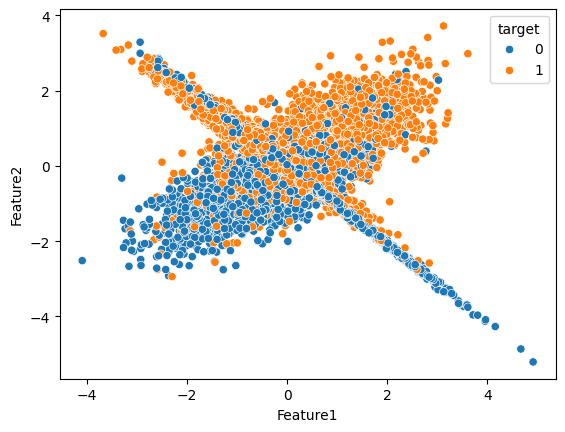

In [22]:
df = pd.DataFrame(X, columns=["Feature1", "Feature2"])
df["target"] = y

sns.scatterplot(data=df, x="Feature1", y="Feature2", hue="target")

In [23]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=584)

In [24]:
print("Shape of X- Train: ",X_train.shape)
print("Shape of X- Test: ",X_test.shape)
print("Shape of y- Train: ",y_train.shape)
print("Shape of y- Test: ",y_test.shape)

Shape of X- Train:  (7000, 2)
Shape of X- Test:  (3000, 2)
Shape of y- Train:  (7000,)
Shape of y- Test:  (3000,)


In [25]:
# Linear Kernel
svc_linear = SVC(kernel='linear', probability=True)
svc_linear.fit(X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [26]:
# RBF Kernel
svc_rbf = SVC(kernel='rbf', probability=True)
svc_rbf.fit(X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [27]:
# Poly Kernel
svc_poly = SVC(kernel='poly', probability=True)
svc_poly.fit(X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [28]:
# Poly Kernel
svc_sigmoid = SVC(kernel='sigmoid', probability=True)
svc_sigmoid.fit(X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'sigmoid'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [29]:
def get_model_metrics(model, X_train, y_train, X_test, y_test, model_name):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    y_train_prob = model.predict_proba(X_train)[:, 1]
    y_test_prob = model.predict_proba(X_test)[:, 1]

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    train_auc = roc_auc_score(y_train, y_train_prob)
    test_auc = roc_auc_score(y_test, y_test_prob)

    train_gini = 2 * train_auc - 1
    test_gini = 2 * test_auc - 1

    ks_stat, _ = ks_2samp(y_test_prob[y_test == 0], y_test_prob[y_test == 1])

    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)

    return {
        "Model": model_name,
        "Train Accuracy": round(train_accuracy, 4),
        "Test Accuracy": round(test_accuracy, 4),
        "Train AUC": round(train_auc, 4),
        "Test AUC": round(test_auc, 4),
        "Train GINI": round(train_gini, 4),
        "Test GINI": round(test_gini, 4),
        "Test KS": round(ks_stat, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1 Score": round(f1, 4),
    }

In [30]:
results = []

results.append(
    get_model_metrics(
        svc_linear, X_train, y_train, X_test, y_test,
        model_name="SVC - Kernel: Linear"
    )
)

results.append(
    get_model_metrics(
       svc_rbf, X_train, y_train, X_test, y_test,
        model_name="SVC - Kernel: rbf"
    )
)

results.append(
    get_model_metrics(
        svc_poly, X_train, y_train, X_test, y_test,
        model_name="SVC - Kernel: poly"
    )
)

results.append(
    get_model_metrics(
        svc_sigmoid, X_train, y_train, X_test, y_test,
        model_name="SVC - Kernel: sigmoid"
    )
)

results_df = pd.DataFrame(results)
results_df

,Model,Train Accuracy,Test Accuracy,Train AUC,Test AUC,Train GINI,Test GINI,Test KS,Precision,Recall,F1 Score
0,SVC - Kernel: Linear,0.6973,0.6997,0.7627,0.7631,0.5253,0.5262,0.4071,0.6949,0.7211,0.7078
1,SVC - Kernel: rbf,0.6994,0.7020,0.7536,0.7535,0.5072,0.5070,0.4091,0.6919,0.7376,0.7140
2,SVC - Kernel: poly,0.6780,0.6727,0.7569,0.7547,0.5138,0.5093,0.3732,0.6281,0.8605,0.7262
3,SVC - Kernel: sigmoid,0.5563,0.5647,0.5793,0.5834,0.1587,0.1668,0.1384,0.5690,0.5638,0.5664


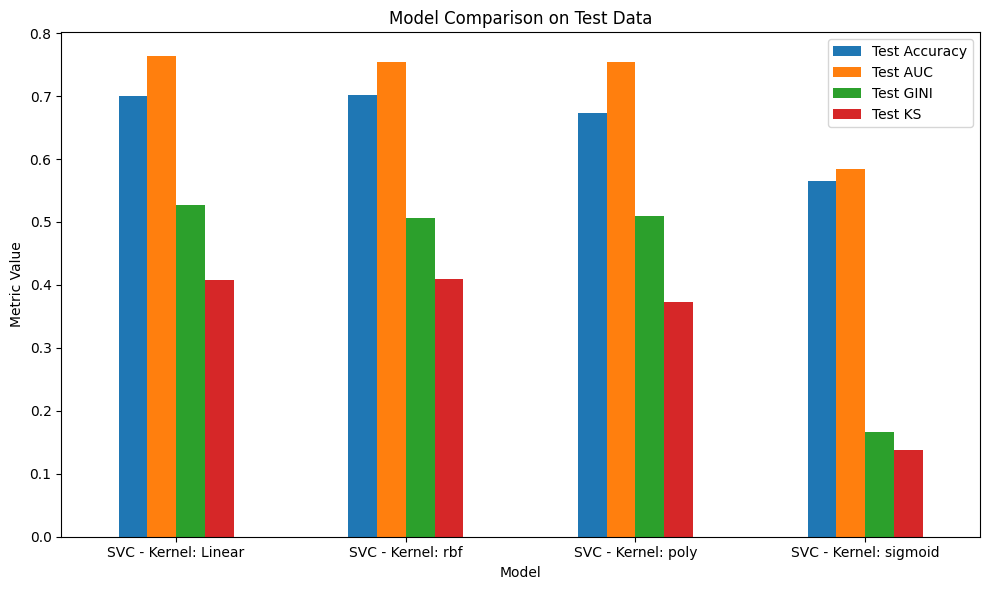

In [31]:
plot_df = results_df[["Model", "Test Accuracy", "Test AUC", "Test GINI", "Test KS"]]
plot_df = plot_df.set_index("Model")

plot_df.plot(kind="bar", figsize=(10, 6))
plt.title("Model Comparison on Test Data")
plt.ylabel("Metric Value")
plt.xticks(rotation=0)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

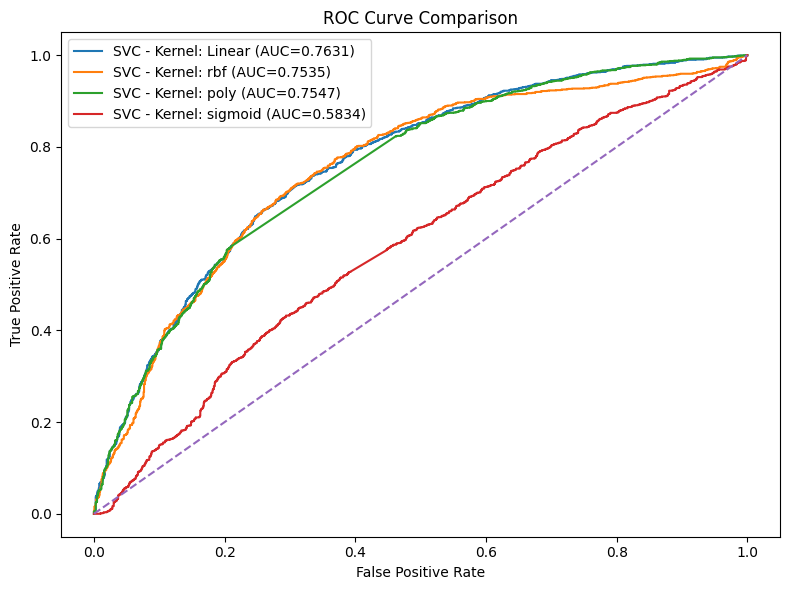

In [32]:
models_dict = {
    "SVC - Kernel: Linear": svc_linear,
    "SVC - Kernel: rbf": svc_rbf,
    "SVC - Kernel: poly": svc_poly,
    "SVC - Kernel: sigmoid": svc_sigmoid
}

plt.figure(figsize=(8, 6))

for name, model in models_dict.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

### All the evaluation metrics have declined, so instead of using the default SVM settings, let’s apply Grid Search for rbf to identify the best combination of hyperparameters and fit a more optimal decision boundary

In [33]:
print("Shape of X- Train: ",X_train.shape)
print("Shape of X- Test: ",X_test.shape)
print("Shape of y- Train: ",y_train.shape)
print("Shape of y- Test: ",y_test.shape)

Shape of X- Train:  (7000, 2)
Shape of X- Test:  (3000, 2)
Shape of y- Train:  (7000,)
Shape of y- Test:  (3000,)


In [62]:
param_grid = [
    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 9, 10, 12, 14, 15, 100],
        'gamma': [1, 10, 20, 30, 40, 50]
    }
]


In [63]:

grid = GridSearchCV(
    estimator=SVC(probability=True),
    param_grid=param_grid,
    scoring='roc_auc',
    refit=True,
    cv=5,
    n_jobs=-1,
    verbose=3
)


In [64]:
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best AUC Score:", grid.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters: {'C': 10, 'gamma': 20, 'kernel': 'rbf'}
Best AUC Score: 0.7853670781708235


========== Train Data Metrics ==========
Accuracy       : 0.7600
AUC            : 0.8316
GINI           : 0.6631
KS Statistic   : 0.5294
KS p-value     : 0.0000

========== Classification Report: Train Data ==========
              precision    recall  f1-score   support

           0       0.75      0.79      0.77      3515
           1       0.77      0.73      0.75      3485

    accuracy                           0.76      7000
   macro avg       0.76      0.76      0.76      7000
weighted avg       0.76      0.76      0.76      7000


========== Confusion Matrix: Train Data ==========
[[2762  753]
 [ 927 2558]]

========== ROC Curve: Train Data ==========


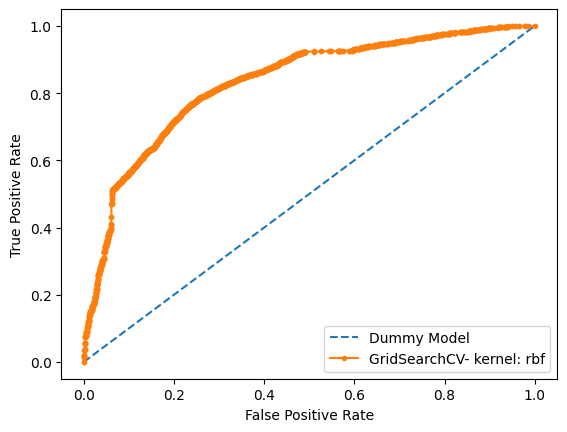

In [65]:
x_pred_grid = grid.predict(X_train)
x_prob_grid  = grid.predict_proba(X_train)[:, 1]

accuracy = accuracy_score(y_train, x_pred_grid )
auc = roc_auc_score(y_train, x_prob_grid )
gini = 2 * auc - 1
ks_stat, ks_pvalue = ks_2samp(x_prob_grid [y_train == 0], x_prob_grid [y_train == 1])

print("========== Train Data Metrics ==========")
print(f"Accuracy       : {accuracy:.4f}")
print(f"AUC            : {auc:.4f}")
print(f"GINI           : {gini:.4f}")
print(f"KS Statistic   : {ks_stat:.4f}")
print(f"KS p-value     : {ks_pvalue:.4f}")

print("\n========== Classification Report: Train Data ==========")
print(classification_report(y_train, x_pred_grid ))

print("\n========== Confusion Matrix: Train Data ==========")
print(confusion_matrix(y_train, x_pred_grid ))

print("\n========== ROC Curve: Train Data ==========")
dummy_model_prob = [0 for _ in range(len(y_train))]
dummy_fpr, dummy_tpr, _ = roc_curve(y_train, dummy_model_prob)
model_fpr, model_tpr, thresholds = roc_curve(y_train, x_prob_grid)

# plot the roc curve for the model
plt.plot(dummy_fpr, dummy_tpr, linestyle='--', label='Dummy Model')
plt.plot(model_fpr, model_tpr, marker='.', label='GridSearchCV- kernel: rbf')
# axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# show the legend
plt.legend()
# show the plot
plt.show()

========== Test Data Metrics ==========
Accuracy       : 0.7237
AUC            : 0.7763
GINI           : 0.5526
KS Statistic   : 0.4574
KS p-value     : 0.0000

========== Classification Report: Test Data ==========
              precision    recall  f1-score   support

           0       0.71      0.75      0.73      1487
           1       0.74      0.70      0.72      1513

    accuracy                           0.72      3000
   macro avg       0.72      0.72      0.72      3000
weighted avg       0.72      0.72      0.72      3000


========== Confusion Matrix: Test Data ==========
[[1116  371]
 [ 458 1055]]

========== ROC Curve: Test Data ==========


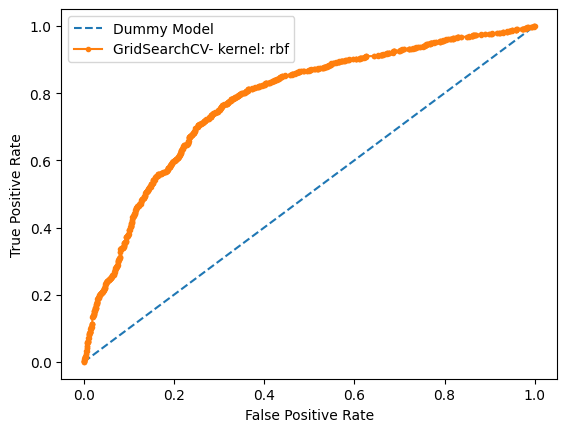

In [66]:
y_pred_grid = grid.predict(X_test)
y_prob_grid  = grid.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred_grid )
auc = roc_auc_score(y_test, y_prob_grid )
gini = 2 * auc - 1
ks_stat, ks_pvalue = ks_2samp(y_prob_grid [y_test == 0], y_prob_grid [y_test == 1])

print("========== Test Data Metrics ==========")
print(f"Accuracy       : {accuracy:.4f}")
print(f"AUC            : {auc:.4f}")
print(f"GINI           : {gini:.4f}")
print(f"KS Statistic   : {ks_stat:.4f}")
print(f"KS p-value     : {ks_pvalue:.4f}")

print("\n========== Classification Report: Test Data ==========")
print(classification_report(y_test, y_pred_grid ))

print("\n========== Confusion Matrix: Test Data ==========")
print(confusion_matrix(y_test, y_pred_grid ))

print("\n========== ROC Curve: Test Data ==========")
dummy_model_prob = [0 for _ in range(len(y_test))]
dummy_fpr, dummy_tpr, _ = roc_curve(y_test, dummy_model_prob)
model_fpr, model_tpr, thresholds = roc_curve(y_test, y_prob_grid)

# plot the roc curve for the model
plt.plot(dummy_fpr, dummy_tpr, linestyle='--', label='Dummy Model')
plt.plot(model_fpr, model_tpr, marker='.', label='GridSearchCV- kernel: rbf')
# axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# show the legend
plt.legend()
# show the plot
plt.show()

In [67]:
results = []

results.append(
    get_model_metrics(
        grid.best_estimator_, X_train, y_train, X_test, y_test,
        model_name="Grid Search - Kernel: rbf"
    )
)

results.append(
    get_model_metrics(
        svc_linear, X_train, y_train, X_test, y_test,
        model_name="SVC - Kernel: Linear"
    )
)

results.append(
    get_model_metrics(
       svc_rbf, X_train, y_train, X_test, y_test,
        model_name="SVC - Kernel: rbf"
    )
)

results.append(
    get_model_metrics(
        svc_poly, X_train, y_train, X_test, y_test,
        model_name="SVC - Kernel: poly"
    )
)

results.append(
    get_model_metrics(
        svc_sigmoid, X_train, y_train, X_test, y_test,
        model_name="SVC - Kernel: sigmoid"
    )
)



results_df = pd.DataFrame(results)
results_df

,Model,Train Accuracy,Test Accuracy,Train AUC,Test AUC,Train GINI,Test GINI,Test KS,Precision,Recall,F1 Score
0,Grid Search - Kernel: rbf,0.7600,0.7237,0.8316,0.7763,0.6631,0.5526,0.4574,0.7398,0.6973,0.7179
1,SVC - Kernel: Linear,0.6973,0.6997,0.7627,0.7631,0.5253,0.5262,0.4071,0.6949,0.7211,0.7078
2,SVC - Kernel: rbf,0.6994,0.7020,0.7536,0.7535,0.5072,0.5070,0.4091,0.6919,0.7376,0.7140
3,SVC - Kernel: poly,0.6780,0.6727,0.7569,0.7547,0.5138,0.5093,0.3732,0.6281,0.8605,0.7262
4,SVC - Kernel: sigmoid,0.5563,0.5647,0.5793,0.5834,0.1587,0.1668,0.1384,0.5690,0.5638,0.5664


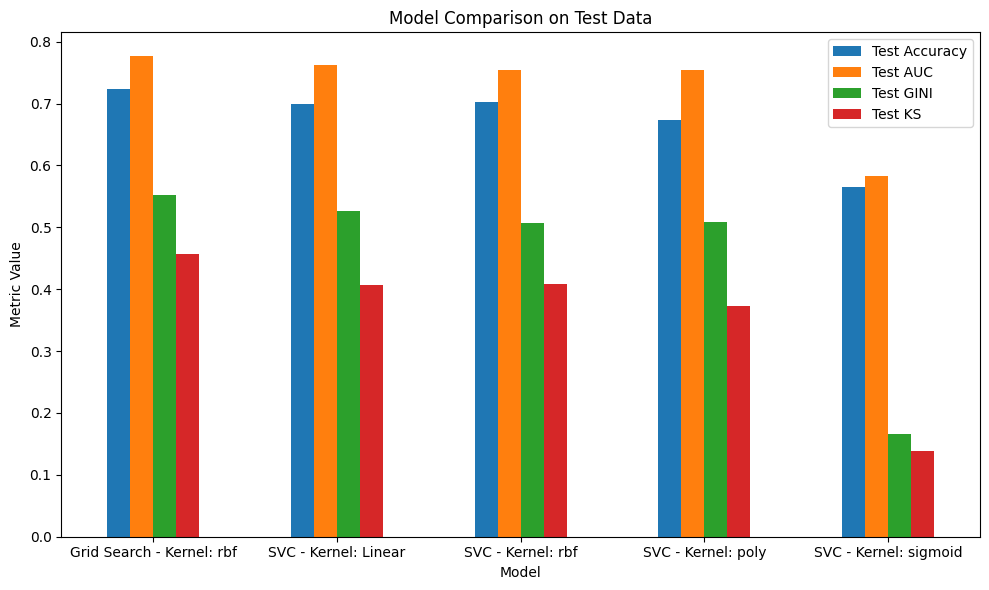

In [68]:
plot_df = results_df[["Model", "Test Accuracy", "Test AUC", "Test GINI", "Test KS"]]
plot_df = plot_df.set_index("Model")

plot_df.plot(kind="bar", figsize=(10, 6))
plt.title("Model Comparison on Test Data")
plt.ylabel("Metric Value")
plt.xticks(rotation=0)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

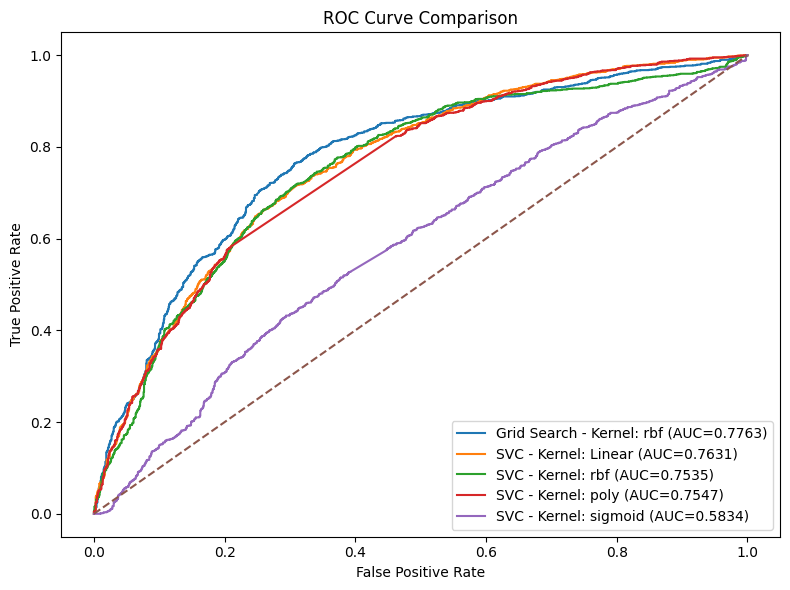

In [69]:
models_dict = {
    "Grid Search - Kernel: rbf": grid.best_estimator_,
    "SVC - Kernel: Linear": svc_linear,
    "SVC - Kernel: rbf": svc_rbf,
    "SVC - Kernel: poly": svc_poly,
    "SVC - Kernel: sigmoid": svc_sigmoid
}

plt.figure(figsize=(8, 6))

for name, model in models_dict.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

### Building a Non-Linearly Separable Dataset and Comparing Manual Feature Transformation with RBF and Polynomial Kernels

In [2]:
x = np.linspace(-5.0, 5.0, 1000)
y = np.sqrt(10**2 - x**2)
y=np.hstack([y,-y])
x=np.hstack([x,-x])

x1 = np.linspace(-5.0, 5.0, 1000)
y1 = np.sqrt(5**2 - x1**2)
y1=np.hstack([y1,-y1])
x1=np.hstack([x1,-x1])

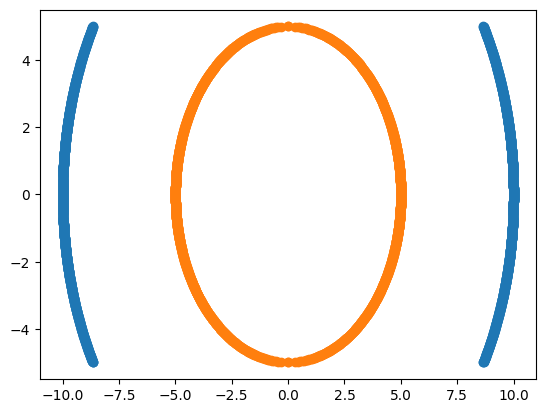

In [3]:
plt.scatter(y,x)
plt.scatter(y1,x1)

In [4]:
df1 =pd.DataFrame(np.vstack([y,x]).T,columns=['X1','X2'])
df1['Y']=0
df2 =pd.DataFrame(np.vstack([y1,x1]).T,columns=['X1','X2'])
df2['Y']=1


In [5]:
df=pd.concat([df1, df2])
df.head(5)

,X1,X2,Y
0,8.660254,-5.00000,0
1,8.666026,-4.98999,0
2,8.671782,-4.97998,0
3,8.677523,-4.96997,0
4,8.683248,-4.95996,0


In [ ]:
## before transformation
X = df[['X1','X2']]
y = df['Y']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=584)
print("Shape of X- Train: ",X_train.shape)
print("Shape of X- Test: ",X_test.shape)
print("Shape of y- Train: ",y_train.shape)
print("Shape of y- Test: ",y_test.shape)

Shape of X- Train:  (3000, 2)
Shape of X- Test:  (1000, 2)
Shape of y- Train:  (3000,)
Shape of y- Test:  (1000,)


In [11]:
linear = SVC(kernel="linear")
linear.fit(X_train, y_train)
y_pred = linear.predict(X_test)
print("Linear kernel Accuracy Score ",accuracy_score(y_test, y_pred))

Linear kernel Accuracy Score  0.469


In [12]:
rbf = SVC(kernel="rbf")
rbf.fit(X_train, y_train)
y_pred = rbf.predict(X_test)
print("rbf kernel Accuracy Score ",accuracy_score(y_test, y_pred))

rbf kernel Accuracy Score  1.0


In [13]:
poly = SVC(kernel="poly")
poly.fit(X_train, y_train)
y_pred = poly.predict(X_test)
print("poly kernel Accuracy Score ",accuracy_score(y_test, y_pred))

poly kernel Accuracy Score  0.622


In [15]:
sigmod = SVC(kernel="sigmoid")
sigmod.fit(X_train, y_train)
y_pred = sigmod.predict(X_test)
print("sigmod kernel Accuracy Score ",accuracy_score(y_test, y_pred))

sigmod kernel Accuracy Score  0.506


In [16]:
# We need to find components for the Polynomical Kernel
#X1,X2,X1_square,X2_square,X1*X2
df['X1_Square']= df['X1']**2
df['X2_Square']= df['X2']**2
df['X1*X2'] = (df['X1'] *df['X2'])
df.head()

,X1,X2,Y,X1_Square,X2_Square,X1*X2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.666026,-4.98999,0,75.100000,24.900000,-43.243381
2,8.671782,-4.97998,0,75.199799,24.800201,-43.185300
3,8.677523,-4.96997,0,75.299398,24.700602,-43.127027
4,8.683248,-4.95996,0,75.398797,24.601203,-43.068563


In [17]:
fig = px.scatter_3d(df, x='X1', y='X2', z='X1*X2',
              color='Y')
fig.show()

In [8]:
fig = px.scatter_3d(df, x='X1_Square', y='X1_Square', z='X1*X2',
              color='Y')
fig.show()

In [18]:
X = df[['X1','X2','X1_Square','X2_Square','X1*X2']]
y = df['Y']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=584)
print("Shape of X- Train: ",X_train.shape)
print("Shape of X- Test: ",X_test.shape)
print("Shape of y- Train: ",y_train.shape)
print("Shape of y- Test: ",y_test.shape)

Shape of X- Train:  (3000, 5)
Shape of X- Test:  (1000, 5)
Shape of y- Train:  (3000,)
Shape of y- Test:  (1000,)


In [19]:
linear = SVC(kernel="linear")
linear.fit(X_train, y_train)
y_pred = linear.predict(X_test)
print("Linear kernel Accuracy Score ",accuracy_score(y_test, y_pred))
rbf = SVC(kernel="rbf")
rbf.fit(X_train, y_train)
y_pred = rbf.predict(X_test)
print("rbf kernel Accuracy Score ",accuracy_score(y_test, y_pred))
poly = SVC(kernel="poly")
poly.fit(X_train, y_train)
y_pred = poly.predict(X_test)
print("poly kernel Accuracy Score ",accuracy_score(y_test, y_pred))
sigmod = SVC(kernel="sigmoid")
sigmod.fit(X_train, y_train)
y_pred = sigmod.predict(X_test)
print("sigmod kernel Accuracy Score ",accuracy_score(y_test, y_pred))

Linear kernel Accuracy Score  1.0
rbf kernel Accuracy Score  1.0
poly kernel Accuracy Score  1.0
sigmod kernel Accuracy Score  1.0


## SVR (Support Vector regression)

In [50]:
df=sns.load_dataset('tips')

In [21]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [23]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [24]:
df['sex'].value_counts()

sex
Male      157
Female     87
Name: count, dtype: int64

In [25]:
df['smoker'].value_counts()

smoker
No     151
Yes     93
Name: count, dtype: int64

In [28]:
df['time'].value_counts()

time
Dinner    176
Lunch      68
Name: count, dtype: int64

In [29]:
df['day'].value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

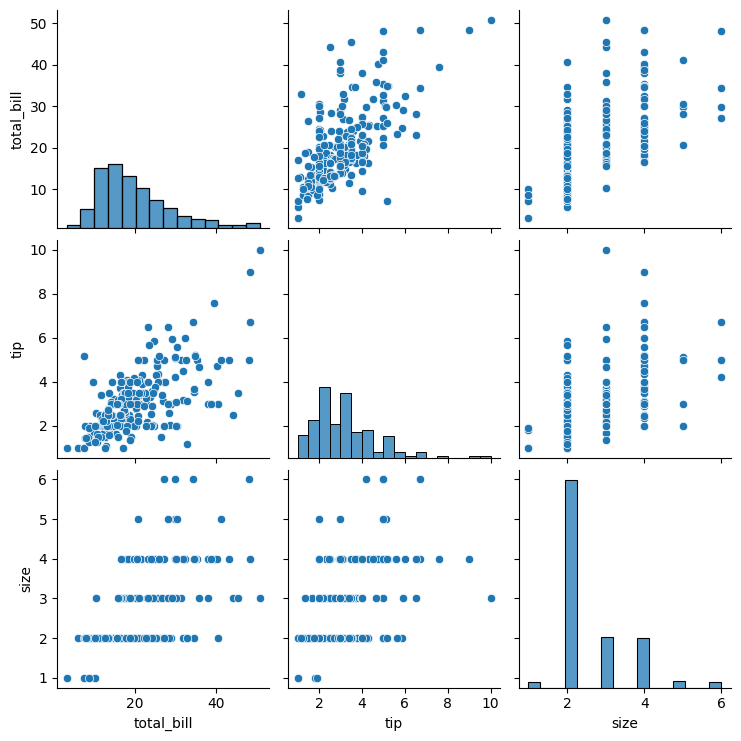

In [51]:
sns.pairplot(df)

In [52]:
## independnent and dependent features
X=df[['tip', 'sex', 'smoker', 'day', 'time', 'size']]
y=df['total_bill']

In [53]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=584)
print("Shape of X- Train: ",X_train.shape)
print("Shape of X- Test: ",X_test.shape)
print("Shape of y- Train: ",y_train.shape)
print("Shape of y- Test: ",y_test.shape)

Shape of X- Train:  (183, 6)
Shape of X- Test:  (61, 6)
Shape of y- Train:  (183,)
Shape of y- Test:  (61,)


##### Feature Encoding(Label Encoding And Onehot Encoding)

In [54]:
# Applying Label Encoding
le1=LabelEncoder()
le2=LabelEncoder()
le3=LabelEncoder()
X_train['sex']=le1.fit_transform(X_train['sex'])
X_train['smoker']=le2.fit_transform(X_train['smoker'])
X_train['time']=le3.fit_transform(X_train['time'])

# To avoid data leakage, apply the tranform on X_test data

X_test['sex']=le1.transform(X_test['sex'])
X_test['smoker']=le2.transform(X_test['smoker'])
X_test['time']=le3.transform(X_test['time'])

In [55]:
X_train.head()

,tip,sex,smoker,day,time,size
9,3.23,1,0,Sun,0,2
102,2.50,0,1,Sat,0,3
80,3.00,1,1,Thur,1,2
209,2.23,0,1,Sat,0,2
43,1.32,1,0,Sun,0,2


In [56]:
X_test.head()

,tip,sex,smoker,day,time,size
21,2.75,0,0,Sat,0,2
137,2.00,0,0,Thur,1,2
32,3.00,0,0,Sat,0,2
203,2.50,0,1,Thur,1,2
93,4.30,0,1,Fri,0,2


In [57]:
# Applying OneHot Encoding
ct = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(drop='first', sparse_output=False), ['day'])
    ],
    remainder='passthrough'
)
X_train=ct.fit_transform(X_train)
X_test=ct.transform(X_test)


In [58]:
# Convert back to DataFrame with column names
feature_names = ct.get_feature_names_out()
X_train = pd.DataFrame(X_train, columns=feature_names)
X_test = pd.DataFrame(X_test, columns=feature_names)

In [59]:
X_train.head()

,onehot__day_Sat,onehot__day_Sun,onehot__day_Thur,remainder__tip,remainder__sex,remainder__smoker,remainder__time,remainder__size
0,0.0,1.0,0.0,3.23,1.0,0.0,0.0,2.0
1,1.0,0.0,0.0,2.50,0.0,1.0,0.0,3.0
2,0.0,0.0,1.0,3.00,1.0,1.0,1.0,2.0
3,1.0,0.0,0.0,2.23,0.0,1.0,0.0,2.0
4,0.0,1.0,0.0,1.32,1.0,0.0,0.0,2.0


In [60]:
X_test.head()

,onehot__day_Sat,onehot__day_Sun,onehot__day_Thur,remainder__tip,remainder__sex,remainder__smoker,remainder__time,remainder__size
0,1.0,0.0,0.0,2.75,0.0,0.0,0.0,2.0
1,0.0,0.0,1.0,2.00,0.0,0.0,1.0,2.0
2,1.0,0.0,0.0,3.00,0.0,0.0,0.0,2.0
3,0.0,0.0,1.0,2.50,0.0,1.0,1.0,2.0
4,0.0,0.0,0.0,4.30,0.0,1.0,0.0,2.0


In [61]:
print("Shape of X- Train: ",X_train.shape)
print("Shape of X- Test: ",X_test.shape)
print("Shape of y- Train: ",y_train.shape)
print("Shape of y- Test: ",y_test.shape)

Shape of X- Train:  (183, 8)
Shape of X- Test:  (61, 8)
Shape of y- Train:  (183,)
Shape of y- Test:  (61,)


In [74]:
svr_linear=SVR(kernel='linear')
svr_rbf=SVR(kernel='rbf')
svr_poly=SVR(kernel='poly')
svr_sigmoid=SVR(kernel='sigmoid')


In [75]:
svr_linear.fit(X_train,y_train)
svr_rbf.fit(X_train,y_train)
svr_poly.fit(X_train,y_train)
svr_sigmoid.fit(X_train,y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'sigmoid'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [76]:
def get_reg_model_metrics(model, X_train, y_train, X_test, y_test, model_name):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    mse_train = mean_squared_error(y_train,y_train_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train,y_train_pred))
    mae_train = mean_absolute_error(y_train,y_train_pred)
    r2_train = r2_score(y_train,y_train_pred)
    adjr2_train= (1 -(1-r2_score(y_train,y_train_pred))*(len(y_train)-1)/(len(y_train)-X_train.shape[1]-1))

    mse_test = mean_squared_error(y_test,y_test_pred)
    rmse_test = np.sqrt(mean_squared_error(y_test,y_test_pred))
    mae_test = mean_absolute_error(y_test,y_test_pred)
    r2_test = r2_score(y_test,y_test_pred)
    adjr2_test= (1 -(1-r2_score(y_test,y_test_pred))*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))

    return {
        "Model": model_name,
        "Train MSE": round(mse_train, 4),
        "Test MSE": round(mse_test, 4),
        "Train RMSE": round(rmse_train, 4),
        "Test RMSE": round(rmse_test, 4),
        "Train MAE": round(mae_train, 4),
        "Test MAE": round(mae_test, 4),
        "Train R2": round(r2_train, 4),
        "Test R2": round(r2_test, 4),
        "Train Adj-R2": round(adjr2_train, 4),
        "Test Adj-R2": round(adjr2_test, 4)

    }


In [ ]:
results_svr = []


results_svr.append(
    get_reg_model_metrics(
        svr_linear, X_train, y_train, X_test, y_test,
        model_name="SVC - Kernel: Linear"
    )
)

results_svr.append(
    get_reg_model_metrics(
       svr_rbf, X_train, y_train, X_test, y_test,
        model_name="SVC - Kernel: rbf"
    )
)

results_svr.append(
    get_reg_model_metrics(
        svr_poly, X_train, y_train, X_test, y_test,
        model_name="SVC - Kernel: poly"
    )
)

results_svr.append(
    get_reg_model_metrics(
        svr_sigmoid, X_train, y_train, X_test, y_test,
        model_name="SVC - Kernel: sigmoid"
    )
)

results_svr_df = pd.DataFrame(results_svr)
results_svr_df

,Model,Train MSE,Test MSE,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2,Train Adj-R2,Test Adj-R2
0,SVC - Kernel: Linear,39.0954,26.0012,6.2526,5.0991,4.2461,3.3818,0.5554,0.4500,0.5349,0.3654
1,SVC - Kernel: rbf,47.6623,27.7045,6.9038,5.2635,4.6050,3.4974,0.4579,0.4140,0.4330,0.3239
2,SVC - Kernel: poly,45.6017,25.1687,6.7529,5.0168,4.6966,3.5961,0.4814,0.4677,0.4575,0.3858
3,SVC - Kernel: sigmoid,157.5479,81.4576,12.5518,9.0254,9.2518,6.8327,-0.7918,-0.7229,-0.8742,-0.9880


### let’s apply Grid Search for rbf to identify the best combination of hyperparameters and fit a more optimal decision boundary

In [99]:
param_grid = [
    {
        'kernel': ['rbf'],
        'C': [100, 110, 120, 130, 140, 150, 175, 200],
        'gamma': [0.0008, 0.001, 0.0012, 0.0014, 0.0016, 0.0018, 0.002, 0.003],
        'epsilon': [0.05, 0.1, 0.15, 0.2]
    }
]


In [100]:

grid = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    scoring={'MSE': 'neg_mean_squared_error', 'R2': 'r2'},
    refit='MSE',
    cv=5,
    n_jobs=-1,
    verbose=3
)


In [101]:
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score (neg MSE):", grid.best_score_)
print("Best CV MSE:", -grid.best_score_)

Fitting 5 folds for each of 256 candidates, totalling 1280 fits
Best Parameters: {'C': 200, 'epsilon': 0.1, 'gamma': 0.001, 'kernel': 'rbf'}
Best CV Score (neg MSE): -41.5117593181957
Best CV MSE: 41.5117593181957


In [102]:
results_svr = []

results_svr.append(
    get_reg_model_metrics(
        grid.best_estimator_, X_train, y_train, X_test, y_test,
        model_name="SVR Grid Search - Kernel: rbf"
    )
)

results_svr.append(
    get_reg_model_metrics(
        svr_linear, X_train, y_train, X_test, y_test,
        model_name="SVC - Kernel: Linear"
    )
)

results_svr.append(
    get_reg_model_metrics(
       svr_rbf, X_train, y_train, X_test, y_test,
        model_name="SVC - Kernel: rbf"
    )
)

results_svr.append(
    get_reg_model_metrics(
        svr_poly, X_train, y_train, X_test, y_test,
        model_name="SVC - Kernel: poly"
    )
)

results_svr.append(
    get_reg_model_metrics(
        svr_sigmoid, X_train, y_train, X_test, y_test,
        model_name="SVC - Kernel: sigmoid"
    )
)

results_svr_df = pd.DataFrame(results_svr)
results_svr_df

,Model,Train MSE,Test MSE,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2,Train Adj-R2,Test Adj-R2
0,SVR Grid Search - Kernel: rbf,39.8225,26.0854,6.3105,5.1074,4.2782,3.3988,0.5471,0.4483,0.5263,0.3634
1,SVC - Kernel: Linear,39.0954,26.0012,6.2526,5.0991,4.2461,3.3818,0.5554,0.4500,0.5349,0.3654
2,SVC - Kernel: rbf,47.6623,27.7045,6.9038,5.2635,4.6050,3.4974,0.4579,0.4140,0.4330,0.3239
3,SVC - Kernel: poly,45.6017,25.1687,6.7529,5.0168,4.6966,3.5961,0.4814,0.4677,0.4575,0.3858
4,SVC - Kernel: sigmoid,157.5479,81.4576,12.5518,9.0254,9.2518,6.8327,-0.7918,-0.7229,-0.8742,-0.9880
